What You're Aiming For
Dataset Selection:
Head over to Kaggle and choose a dataset that aligns with your interests. Ensure it involves either a classification or regression task.
Real-world data can be messy, and that's perfectly fine! You're here to tame it.
Data Preprocessing:
Identify and handle missing values within your dataset. Employ effective strategies for dealing with missing data.
Implement data cleaning, formatting, and organization to prepare your dataset for training.
Feature Engineering:
Enhance your model's performance by creating new features or transforming existing ones.
Tailor your feature engineering techniques to address the specific needs of your chosen project.
Data Visualization:
Utilize data visualization techniques to gain insights into your dataset.
Create visualizations that reveal patterns and relationships, aiding your understanding of the data.
Model Selection:
Choose the right model based on the nature of your problem.
Consider factors such as the task type (classification or regression), dataset size, and alignment with algorithm assumptions.
Model Evaluation:
Evaluate your model's performance using appropriate metrics for the chosen task (accuracy, classification reports, confusion matrices).
Use appropriate methods: hyper parameter tuning, cross validation, etc.
Justify your model selection and discuss the implications of your results.
Project Submission:
Share your code and findings in the assignment section. Provide clear documentation and explanations.
Highlight any challenges faced during the project and how you overcame them.

Instructions
What dataset did you use?
Explain your project! I want to see the thinking behind the code essentially.
e.g. why this project interested you, the steps you took while doing the project, how you decided what model to use.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load the dataset
df = pd.read_csv('personality_datasert.csv')

In [ ]:
# General info
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Handle missing values (use mean for numeric, mode for categorical)
df['Friends_circle_size'].fillna(df['Friends_circle_size'].mean(), inplace=True)
df['Post_frequency'].fillna(df['Post_frequency'].mean(), inplace=True)
df['Time_spent_Alone'].fillna(df['Time_spent_Alone'].mean(), inplace=True)
df['Going_outside'].fillna(df['Going_outside'].mean(), inplace=True)
df['Social_event_attendance'].fillna(df['Social_event_attendance'].mean(), inplace=True)

# Fill categorical columns with mode
for col in ['Stage_fear', 'Drained_after_socializing']:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Stage_fear'] = le.fit_transform(df['Stage_fear'])
df['Drained_after_socializing'] = le.fit_transform(df['Drained_after_socializing'])
df['Personality'] = le.fit_transform(df['Personality'])  # 0 = Extrovert, 1 = Introvert


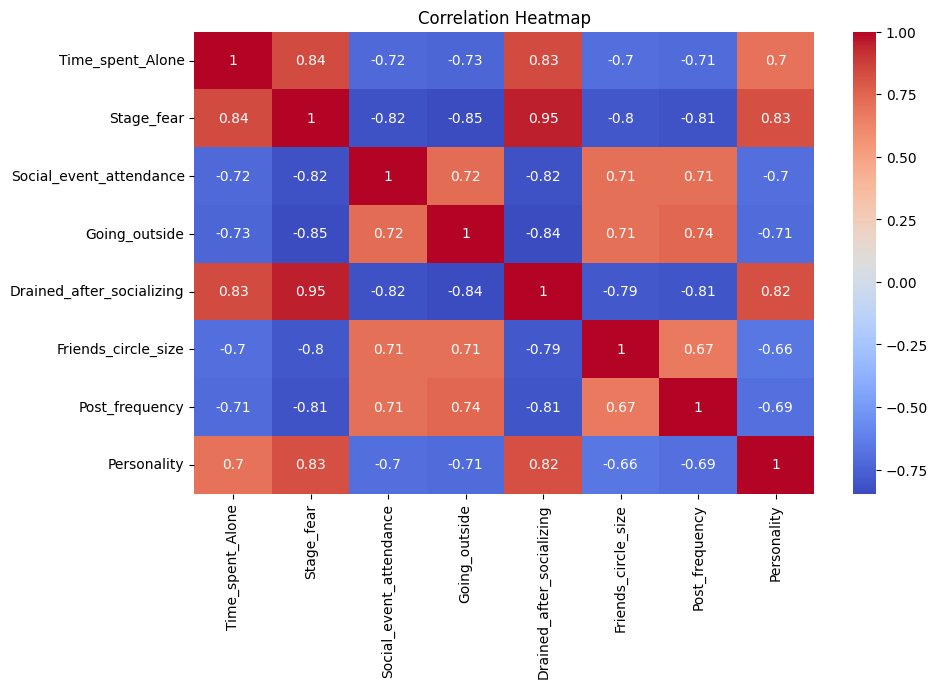

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('Personality', axis=1)
y = df['Personality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


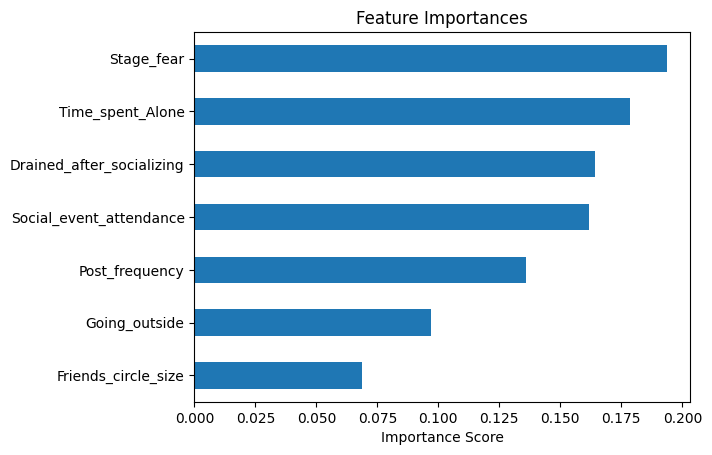

In [9]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title="Feature Importances")
plt.xlabel("Importance Score")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid=params, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Project Title: Personality Prediction – Extrovert vs. Introvert Classifier

Dataset Used:
I used the “Extrovert vs. Introvert Behavior Data” from Kaggle.
This dataset contains behavioral and social interaction data like:

    Time spent alone

    Frequency of going out

    Number of friends

    Social event attendance

    Stage fear

    Drained after socializing

    Personality type (Extrovert or Introvert - the target)

Why This Project?
This project interested me because it combines psychology and machine learning, offering practical use in fields like recruitment, personalized marketing, and mental health analysis. It’s fascinating how measurable behaviors can indicate deeper personality traits. My goal was to build a model that classifies individuals as extroverts or introverts based on their social behaviors.

Steps Taken in the Project:
1. Data Import & Cleaning
I imported the dataset using Pandas and explored the structure using .info() and .describe(). I identified missing values and handled them using the mean (for numerical) and mode (for categorical) imputations. I also removed duplicates if any.

2. Feature Engineering
I encoded categorical features like Stage_fear, Drained_after_socializing, and Personality using Label Encoding to prepare them for modeling.

3. Exploratory Data Analysis (EDA)
Using seaborn and matplotlib, I visualized the correlation between features to understand which variables impact personality classification the most. This helped in feature selection and in confirming data quality.

4. Model Selection
Since this is a binary classification task (Extrovert = 0, Introvert = 1), I tested a few models. I chose Random Forest Classifier because it:

    Handles both numerical and categorical data

    Is robust against overfitting

    Provides feature importance directly

I also considered trying SVM and Logistic Regression as comparative baselines.

5. Model Training & Evaluation
I trained the model using an 80-20 train-test split and evaluated performance using:

    Accuracy Score

    Confusion Matrix

    Classification Report (Precision, Recall, F1-score)

    Random Forest gave strong performance on both training and test sets, indicating good generalization.

6. Model Improvement
I used GridSearchCV to optimize hyperparameters like n_estimators, max_depth, and min_samples_split.
